<a href="https://colab.research.google.com/github/sk27110/basic_ml_hse/blob/task_5/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22homework_05_trees_rf%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы машинного обучения, ПАДиИИ

## НИУ ВШЭ, 2024-25 учебный год

# Домашнее задание 5: Древесные алгоритмы

Задание выполнил(а):

    Кочетков Александр

## Общая информация

__Внимание!__  


* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов
* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [ ]:
import math

def calculate_entropy(class_counts):
    total = sum(class_counts)
    entropy = 0.0

    for count in class_counts:
        if count == 0:
            continue
        p = count / total
        entropy -= p * math.log(p)

    return round(entropy, 2)

class_distribution = [8, 2]
print(calculate_entropy(class_distribution))

0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

При решении регрессии деревом критерием информативности будет MSE, а минимум MSE достигается при предсказании среднего значения.

In [ ]:
np.array([1, 10, 5, 18, 100, 30, 50, 61, 84, 47]).mean()

np.float64(40.6)

## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [ ]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы.


**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [ ]:
import numpy as np
import pandas as pd
from typing import Union, Tuple

def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:

    X = np.array(feature_vector).flatten()
    y = np.array(target_vector).flatten()

    if feature_type == "real":
        sorted_idx = np.argsort(X)
        X_sorted = X[sorted_idx]
        y_sorted = y[sorted_idx]

        unique_X = np.unique(X_sorted)
        thresholds = (unique_X[:-1] + unique_X[1:]) / 2

        ginis = []

        if task == "classification":
            def gini_impurity(y):
                _, counts = np.unique(y, return_counts=True)
                probs = counts / counts.sum()
                return 1 - np.sum(probs ** 2)

            H_total = gini_impurity(y_sorted)
        else:
            def variance(y):
                return np.var(y) if len(y) > 0 else 0.0

            H_total = variance(y_sorted)


        for t in thresholds:
            mask_left = X_sorted <= t
            mask_right = ~mask_left

            y_left = y_sorted[mask_left]
            y_right = y_sorted[mask_right]

            if len(y_left) == 0 or len(y_right) == 0:
                ginis.append(-np.inf)
                continue

            if task == "classification":
                H_left = gini_impurity(y_left)
                H_right = gini_impurity(y_right)
            else:
                H_left = variance(y_left)
                H_right = variance(y_right)

            w_left = len(y_left) / len(y)
            w_right = 1 - w_left

            gain = H_total - (w_left * H_left + w_right * H_right)
            ginis.append(gain)

        ginis = np.array(ginis)
        best_idx = np.argmax(ginis)
        gini_best = ginis[best_idx]
        threshold_best = thresholds[best_idx]
        return thresholds, ginis, threshold_best, gini_best

    else:
        unique_vals = np.unique(X)
        thresholds = unique_vals
        ginis = []

        if task == "classification":
            def gini_impurity(y):
                _, counts = np.unique(y, return_counts=True)
                probs = counts / counts.sum()
                return 1 - np.sum(probs ** 2)

            H_total = gini_impurity(y)
        else:
            def variance(y):
                return np.var(y) if len(y) > 0 else 0.0

            H_total = variance(y)

        for val in thresholds:
            mask_left = X == val
            mask_right = ~mask_left

            y_left = y[mask_left]
            y_right = y[mask_right]

            if len(y_left) == 0 or len(y_right) == 0:
                ginis.append(-np.inf)
                continue

            if task == "classification":
                H_left = gini_impurity(y_left)
                H_right = gini_impurity(y_right)
            else:
                H_left = variance(y_left)
                H_right = variance(y_right)

            w_left = len(y_left) / len(y)
            w_right = 1 - w_left

            gain = H_total - (w_left * H_left + w_right * H_right)
            ginis.append(gain)

        ginis = np.array(ginis)
        best_idx = np.argmax(ginis)
        gini_best = ginis[best_idx]
        threshold_best = thresholds[best_idx]
        return thresholds, ginis, threshold_best, gini_best

Эту функцию можно протестировать на датасете `California`.

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

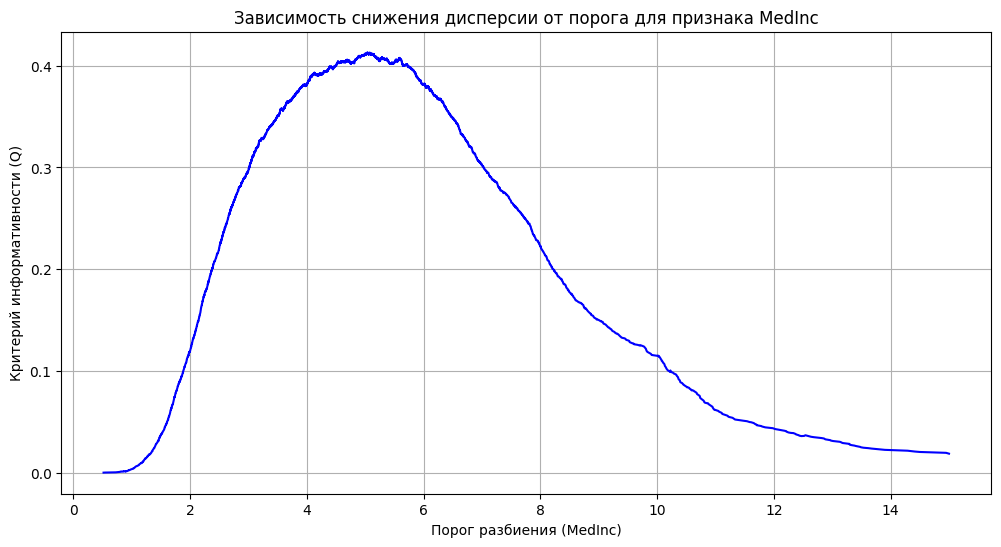

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing


feature_vector = X["MedInc"].values
target_vector = y


thresholds, gains, threshold_best, _ = find_best_split(
    feature_vector,
    target_vector,
    task="regression",
    feature_type="real"
)


plt.figure(figsize=(12, 6))
plt.plot(thresholds, gains, color='blue')
plt.xlabel('Порог разбиения (MedInc)')
plt.ylabel('Критерий информативности (Q)')
plt.title('Зависимость снижения дисперсии от порога для признака MedInc')

plt.grid(True)
plt.show()

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing


best_gain = -np.inf
best_feature = None
best_threshold = None

for feature in X.columns:
    thresholds, gains, threshold_best, gain_best = find_best_split(
        X[feature].values,
        y,
        task="regression",
        feature_type="real"
    )
    if gain_best > best_gain:
        best_gain = gain_best
        best_feature = feature
        best_threshold = threshold_best

print(f"Лучший признак: {best_feature}")
print(f"Лучший порог: {best_threshold:.2f}")
print(f"Значение критерия Q: {best_gain:.2f}")

Лучший признак: MedInc
Лучший порог: 5.04
Значение критерия Q: 0.41


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции.
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в данных и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [ ]:
import numpy as np
from collections import defaultdict, Counter
from typing import Union, List, Dict, Tuple

class DecisionTree:
    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:
        if not all(ft in {"real", "categorical"} for ft in feature_types):
            raise ValueError("Unknown feature type")
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task
        self._tree = {}
        self._feature_importances = defaultdict(float)
        self.classes_ = None

    def _should_stop(self, y: np.ndarray, depth: int) -> bool:
        if self._max_depth is not None and depth >= self._max_depth:
            return True
        if self._min_samples_split is not None and len(y) < self._min_samples_split:
            return True
        if self.task == "classification" and len(np.unique(y)) == 1:
            return True
        return False

    def _calculate_impurity(self, y: np.ndarray, sample_weight: np.ndarray) -> float:
        if self.task == "classification":
            counts = np.bincount(y, weights=sample_weight)
            return 1 - np.sum((counts / np.sum(counts)) ** 2)
        else:
            mean = np.average(y, weights=sample_weight)
            return np.average((y - mean) ** 2, weights=sample_weight)

    def _find_best_split(self, X_col: np.ndarray, y: np.ndarray, sample_weight: np.ndarray,
                        feature_type: str) -> Tuple[float, float, float]:
        if feature_type == "real":
            sorted_idx = np.argsort(X_col)
            X_sorted, y_sorted, w_sorted = X_col[sorted_idx], y[sorted_idx], sample_weight[sorted_idx]
            unique = np.where(np.diff(X_sorted) != 0)[0]
            thresholds = (X_sorted[unique] + X_sorted[unique + 1]) / 2
        else:
            thresholds = np.unique(X_col)

        best_gain = -np.inf
        best_threshold = None

        for threshold in thresholds:
            if feature_type == "real":
                left_mask = X_col <= threshold
            else:
                left_mask = X_col == threshold

            if left_mask.sum() == 0 or left_mask.sum() == len(y):
                continue

            w_left = sample_weight[left_mask]
            w_right = sample_weight[~left_mask]

            h_left = self._calculate_impurity(y[left_mask], w_left)
            h_right = self._calculate_impurity(y[~left_mask], w_right)

            gain = self._calculate_impurity(y, sample_weight) - \
                   (w_left.sum() * h_left + w_right.sum() * h_right) / sample_weight.sum()

            if gain > best_gain:
                best_gain = gain
                best_threshold = threshold

        return best_threshold, best_gain

    def _fit_node(
        self,
        X: np.ndarray,
        y: np.ndarray,
        node: dict,
        sample_weight: np.ndarray,
        depth: int = 0
    ) -> None:
        if self._should_stop(y, depth):
            node["type"] = "terminal"
            if self.task == "classification":
                counts = np.bincount(y, weights=sample_weight)
                node["class"] = np.argmax(counts)
            else:
                node["class"] = np.average(y, weights=sample_weight)
            return

        best_feature = None
        best_threshold = None
        best_gain = -np.inf
        best_missing_weights = (0.5, 0.5)

        for feature in range(X.shape[1]):
            if self._feature_types[feature] == "real":
                valid = ~np.isnan(X[:, feature])
                if valid.sum() == 0:
                    continue

                threshold, gain = self._find_best_split(
                    X[valid, feature], y[valid],
                    sample_weight[valid], "real"
                )
            else:
                valid = ~pd.isna(X[:, feature])
                if valid.sum() == 0:
                    continue

                threshold, gain = self._find_best_split(
                    X[valid, feature], y[valid],
                    sample_weight[valid], "categorical"
                )

            if gain > best_gain:
                best_feature = feature
                best_threshold = threshold
                best_gain = gain

                mask = valid & (X[:, feature] <= threshold if self._feature_types[feature] == "real" else X[:, feature] == threshold)
                w_left = sample_weight[mask].sum()
                w_right = sample_weight[valid & ~mask].sum()
                total = w_left + w_right
                best_missing_weights = (w_left / total if total > 0 else 0.5,
                                      w_right / total if total > 0 else 0.5)

        if best_feature is None:
            node["type"] = "terminal"
            if self.task == "classification":
                counts = np.bincount(y, weights=sample_weight)
                node["class"] = np.argmax(counts)
            else:
                node["class"] = np.average(y, weights=sample_weight)
            return

        node.update({
            "type": "nonterminal",
            "feature": best_feature,
            "threshold": best_threshold,
            "missing_weights": best_missing_weights
        })

        self._feature_importances[best_feature] += best_gain * sample_weight.sum()

        left_mask = X[:, best_feature] <= best_threshold if self._feature_types[best_feature] == "real" else X[:, best_feature] == best_threshold
        missing_mask = np.isnan(X[:, best_feature]) if self._feature_types[best_feature] == "real" else pd.isna(X[:, best_feature])

        left_weights = sample_weight.copy()
        left_weights[missing_mask] *= best_missing_weights[0]
        left_weights[~left_mask & ~missing_mask] = 0

        right_weights = sample_weight.copy()
        right_weights[missing_mask] *= best_missing_weights[1]
        right_weights[left_mask & ~missing_mask] = 0

        node["left"], node["right"] = {}, {}
        self._fit_node(X, y, node["left"], left_weights, depth + 1)
        self._fit_node(X, y, node["right"], right_weights, depth + 1)

    def _predict_node(self, x: np.ndarray, node: dict) -> Union[float, int]:
        if node["type"] == "terminal":
            return node["class"]

        feature_val = x[node["feature"]]
        if pd.isna(feature_val):
            left_pred = self._predict_node(x, node["left"])
            right_pred = self._predict_node(x, node["right"])
            lw, rw = node["missing_weights"]
            return (lw * left_pred + rw * right_pred) / (lw + rw)
        else:
            if self._feature_types[node["feature"]] == "real":
                if feature_val <= node["threshold"]:
                    return self._predict_node(x, node["left"])
                else:
                    return self._predict_node(x, node["right"])
            else:
                if feature_val == node["threshold"]:
                    return self._predict_node(x, node["left"])
                else:
                    return self._predict_node(x, node["right"])

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        if self.task == "classification":
            self.classes_ = np.unique(y)
        self._feature_importances.clear()
        self._fit_node(X, y, self._tree, np.ones(len(y)))

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self._predict_node(x, self._tree) for x in X])

    def get_feature_importances(self, normalize: bool = True) -> Dict[int, float]:
        total = sum(self._feature_importances.values())
        return {f: (imp / total if normalize else imp)
                for f, imp in self._feature_importances.items()}

Обработка пропусков -- как в учебнике яндекса (https://education.yandex.ru/handbook/ml/article/reshayushchiye-derevya)

**Задание 2.3 (1 балл)** Загрузите таблицу `STUDENTS` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

In [ ]:
STUDENTS = 'https://www.dropbox.com/scl/fi/hnmqruw6px5wnm4bip2rz/students.csv?rlkey=ee113i30jnxid3sdxf4oipgkw&dl=1'

In [ ]:
df = pd.read_csv(STUDENTS)
X = df.drop('UNS', axis=1)
y = df['UNS']

<ipython-input-33-ec1f310098b2>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=X[feature], y=y, jitter=0.3, ax=ax2, palette='viridis')
<ipython-input-33-ec1f310098b2>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=X[feature], y=y, jitter=0.3, ax=ax2, palette='viridis')
<ipython-input-33-ec1f310098b2>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=X[feature], y=y, jitter=0.3, ax=ax2, palette='viridis')
<ipython-input-33-ec1f310098b2>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be 

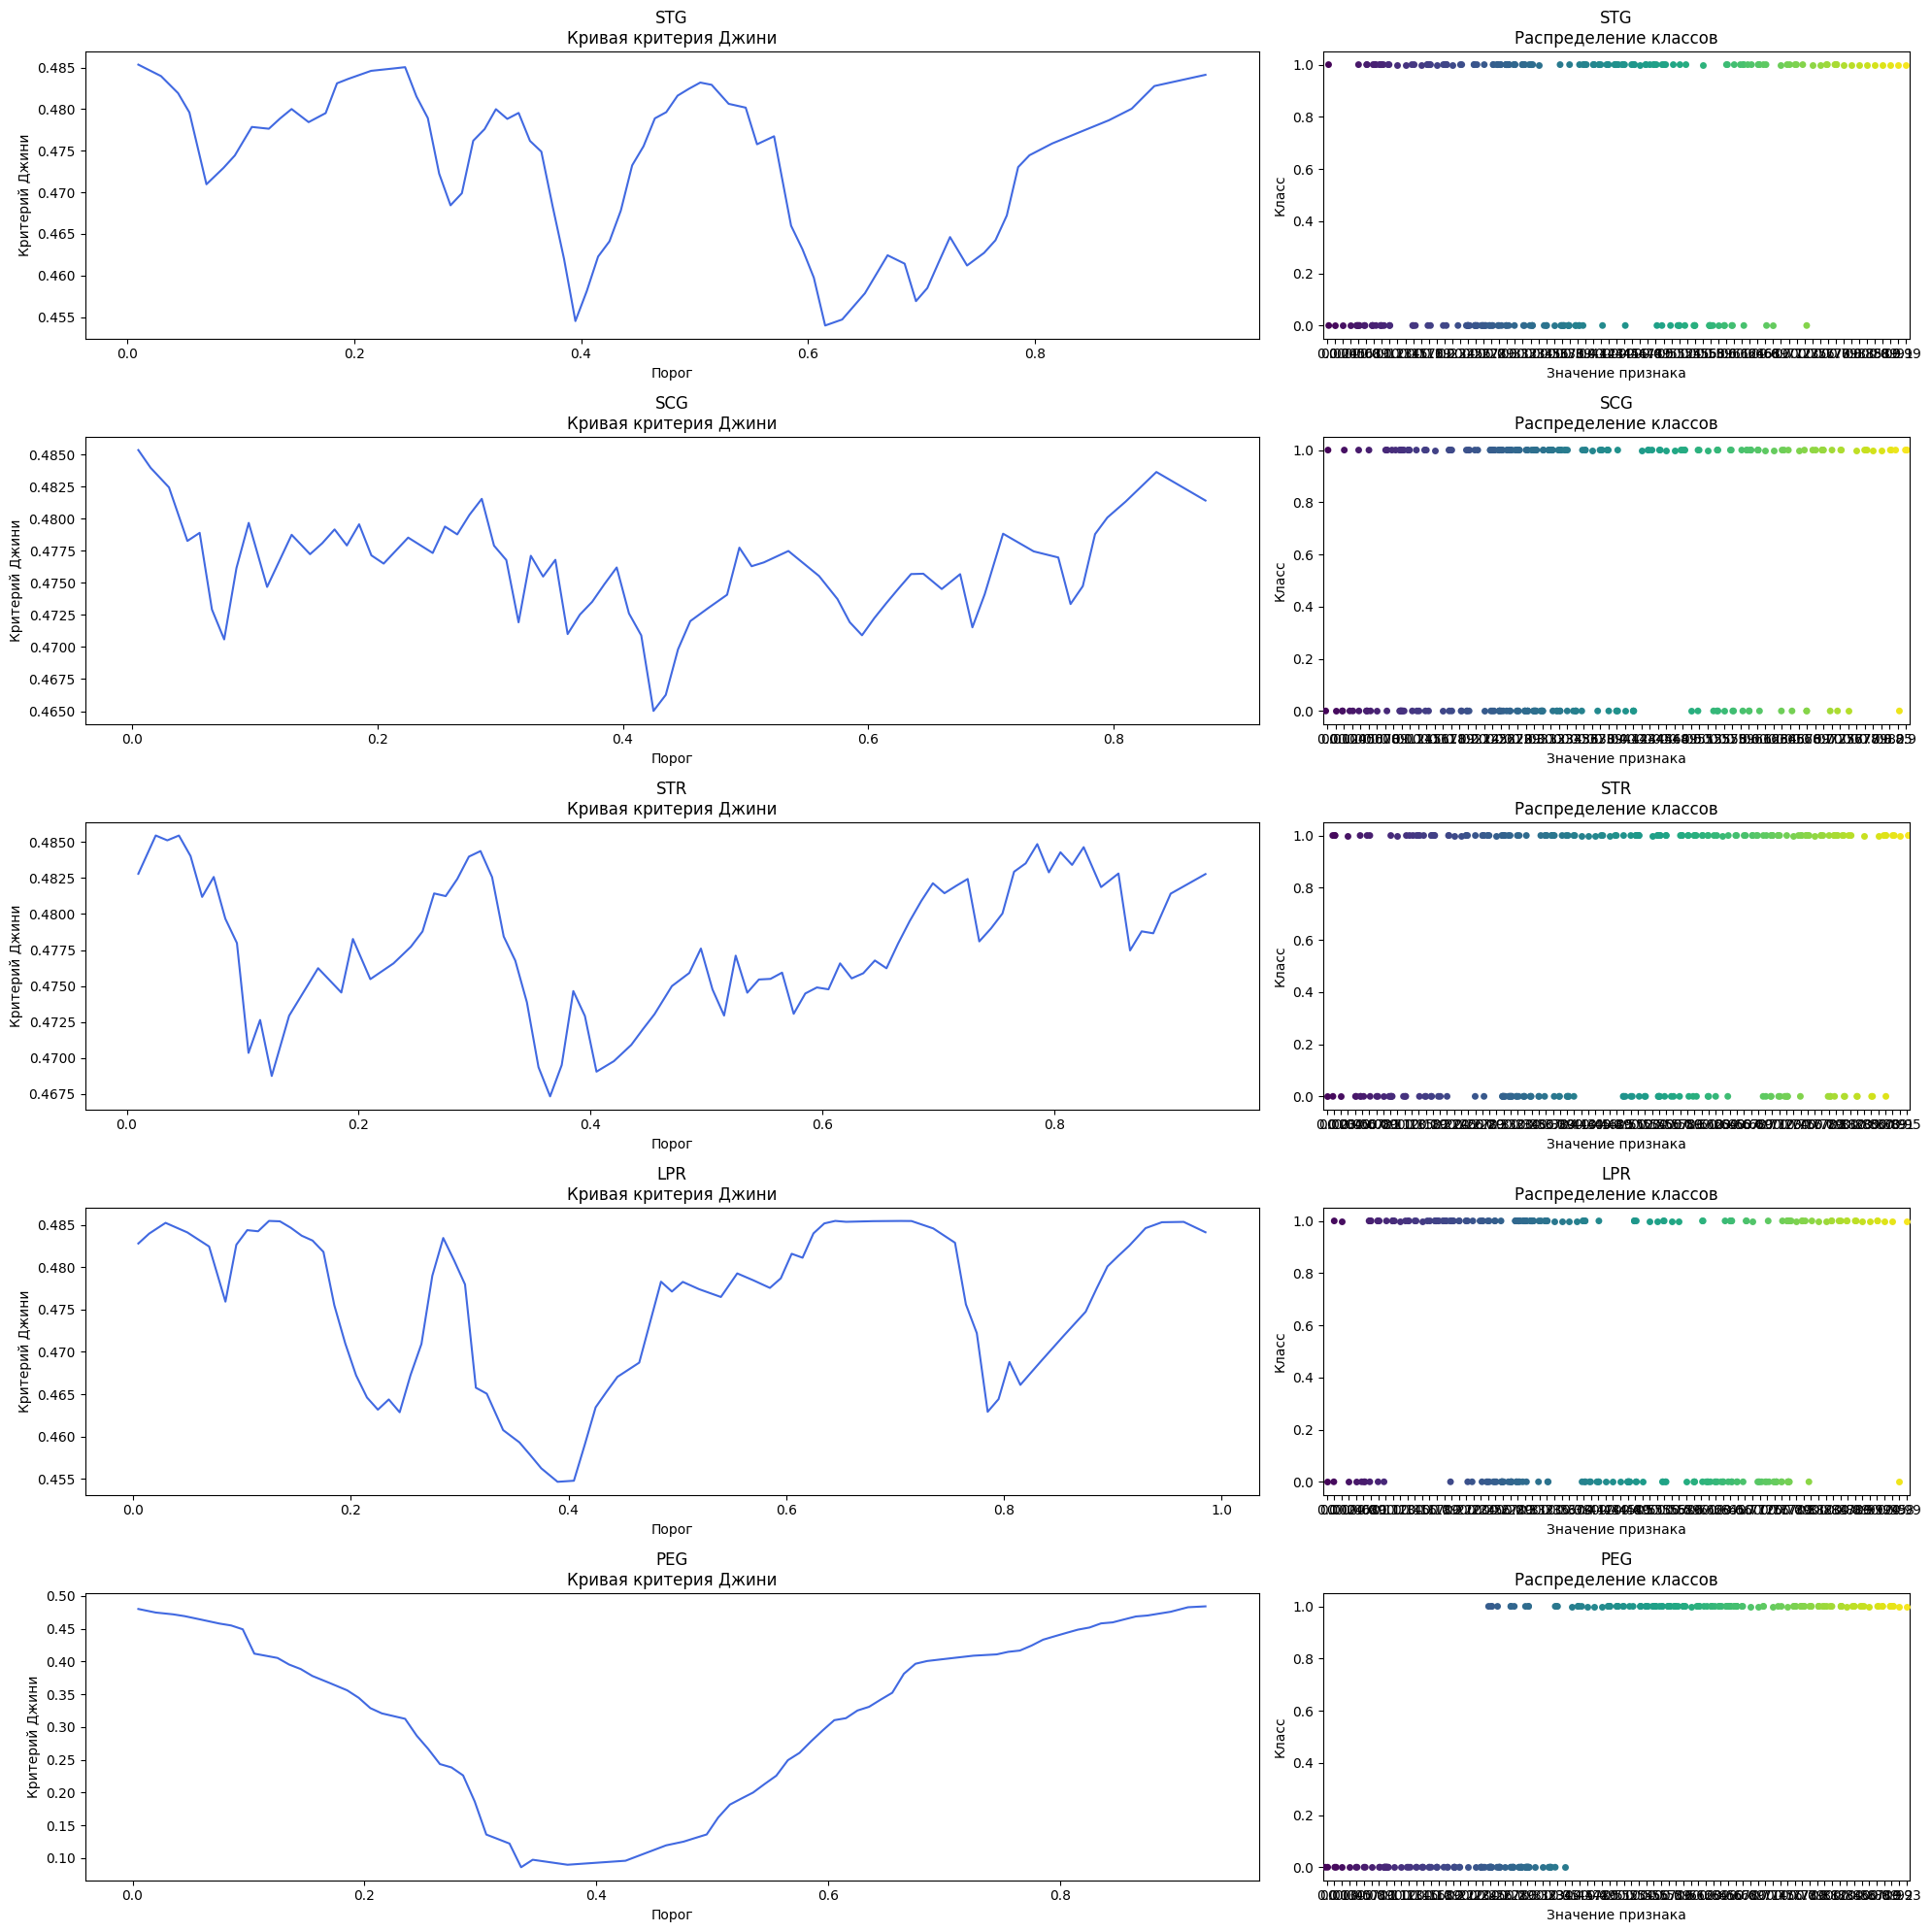

In [33]:
from matplotlib.gridspec import GridSpec
import seaborn as sns

def calculate_gini(y_left, y_right):
    def gini(y):
        p = np.bincount(y) / len(y) if len(y) > 0 else 0
        return 1 - np.sum(p**2)

    n = len(y_left) + len(y_right)
    return (len(y_left)/n * gini(y_left) +
            len(y_right)/n * gini(y_right))

fig = plt.figure(figsize=(20, 20))
gs = GridSpec(5, 2, figure=fig, width_ratios=[2, 1])

for i, feature in enumerate(X.columns):
    data = X[feature].values
    sorted_idx = np.argsort(data)
    data_sorted = data[sorted_idx]
    y_sorted = y.values[sorted_idx]

    thresholds = []
    gini_values = []

    for j in range(1, len(data_sorted)):
        if data_sorted[j] != data_sorted[j-1]:
            threshold = (data_sorted[j] + data_sorted[j-1]) / 2
            left_mask = data_sorted <= threshold
            gini = calculate_gini(y_sorted[left_mask], y_sorted[~left_mask])
            thresholds.append(threshold)
            gini_values.append(gini)

    ax1 = fig.add_subplot(gs[i, 0])
    ax1.plot(thresholds, gini_values, color='royalblue')
    ax1.set_title(f'{feature}\nКривая критерия Джини', fontsize=12)
    ax1.set_xlabel('Порог', fontsize=10)
    ax1.set_ylabel('Критерий Джини', fontsize=10)

    ax2 = fig.add_subplot(gs[i, 1])
    sns.stripplot(x=X[feature], y=y, jitter=0.3, ax=ax2, palette='viridis')
    ax2.set_title(f'{feature}\nРаспределение классов', fontsize=12)
    ax2.set_xlabel('Значение признака', fontsize=10)
    ax2.set_ylabel('Класс', fontsize=10)

plt.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

Лучше всего делить выборку по признаку PEG. Это видно и из графика критерия Джинни (там он с выраженным минимумом и самый маленький из всех), и из диаграммы рассеяиния (видно, что данные сильно отделены).

Кривая для хороших признаков более плавная и имеет ярко выраженный минимум, кривые для плохих признаков не имеют таких минимумов и более хаотичны.

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom).

1. Скачайте таблицу `agaricus-lepiota.data` (из датасета),
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
columns = ["target"] + [f"feature_{i}" for i in range(1, 23)]
df = pd.read_csv(url, header=None, names=columns)

le = LabelEncoder()
df_encoded = df.apply(lambda col: le.fit_transform(col))

X = df_encoded.iloc[:, 1:].values
y = df_encoded.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

tree = DecisionTree(
    feature_types=["categorical"]*22,
    max_depth=5,
    task="classification"
)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

<ipython-input-21-a946f2d4f56e>:37: RuntimeWarning: invalid value encountered in divide
  return 1 - np.sum((counts / np.sum(counts)) ** 2)


Accuracy: 0.9980


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [ ]:
DIABETES = ... # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

In [ ]:
data = pd.read_csv(DIABETES)
print(f"Dataset shape: {data.shape}")
data.head()

Посмотрим на распределение целевой переменной

In [ ]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке.


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации.
3. Выберите ту пару значений, которая даёт наилучшее среднее качество.

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

## Котобонус! (0.25 балла)

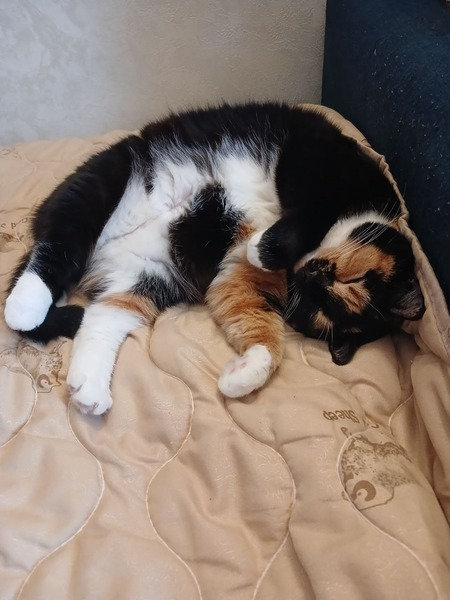

# Обратная связь

Расскажите, как вам это домашнее задание. Было ли оно полезным? Научились ли вы чему то? Насколько сложным по 10-балльной шкале оно вам показалось? Сколько времени у вас ушло на его выполнение? Что следовало ещё в него включить? Было ли что-то лишнее?